# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [ ]:
# Import warnings

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Import the libraries you will be using for analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [ ]:
# Try loading one file

# df = pd.read_parquet('2023-1.parquet')
# df.info()

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

def sample_data(folder_path, frac=0.007, random_state=42):

    # Create a list of all the twelve files to read
    file_list = os.listdir(folder_path)

    # initialise an empty dataframe
    final_df = pd.DataFrame()

    # iterate through the list of files and sample one by one:
    for file_name in file_list:
        try:
            # file path for the current file
            file_path = os.path.join(folder_path, file_name)

            if not file_name.endswith('.parquet'):
              continue

            # Reading the current file
            df = pd.read_parquet(file_path)
            print("Reading:", file_name, "original shape:", df.shape)

            df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

            df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
            df["pickup_date"] = df["tpep_pickup_datetime"].dt.date

            sampled_data = pd.DataFrame()

            for date in df['pickup_date'].unique():
                for hour in range(24):

                    hour_data = df[(df['pickup_date'] == date) & (df['pickup_hour'] == hour)]

                    if len(hour_data) > 0:
                        sample = hour_data.sample(frac=frac, random_state=random_state)
                        # sample all the hourly data from the current month
                        sampled_data = pd.concat([sampled_data, sample], ignore_index = True)


            # Concatenate all the monthly data to a single dataframe
            final_df = pd.concat([final_df, sampled_data], ignore_index = True)

        except Exception as e:
            print(f"Error reading file {file_name}: {e}")

    return final_df

In [ ]:
folder_path = '/content/drive/MyDrive/Upgrad/EDA/EDA_projects/Datasets and Dictionary/trip_records/'
df = sample_data(folder_path)

Reading: 2023-9.parquet original shape: (2817156, 19)


KeyboardInterrupt: 

In [ ]:
df.size

In [ ]:
df.shape

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [ ]:
# Store the df in csv/parquet
df.to_parquet('myfile.parquet', engine='pyarrow')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the new data file

df = pd.read_parquet('/content/drive/MyDrive/Upgrad/EDA/EDA_projects/myfile.parquet')

In [ ]:
df.shape

(285973, 22)

In [ ]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_hour,pickup_date,airport_fee
0,2,2023-09-01 00:39:59,2023-09-01 01:00:28,NaN,4.71,NaN,None,113,238,0,...,0.5,4.32,0.00,1.0,33.15,NaN,NaN,0,2023-09-01,NaN
1,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2.0,0.56,1.0,N,142,142,2,...,0.5,0.00,0.00,1.0,10.10,2.5,0.00,0,2023-09-01,NaN
2,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,N,132,163,1,...,0.5,15.71,6.94,1.0,98.40,2.5,1.75,0,2023-09-01,NaN
3,2,2023-09-01 00:42:13,2023-09-01 01:20:20,2.0,13.71,1.0,N,249,180,4,...,0.5,0.00,0.00,1.0,64.70,2.5,0.00,0,2023-09-01,NaN
4,2,2023-09-01 00:11:38,2023-09-01 00:17:56,1.0,0.71,1.0,N,144,232,1,...,0.5,2.00,0.00,1.0,14.90,2.5,0.00,0,2023-09-01,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285973 entries, 0 to 285972
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               285973 non-null  int64         
 1   tpep_pickup_datetime   285973 non-null  datetime64[us]
 2   tpep_dropoff_datetime  285973 non-null  datetime64[us]
 3   passenger_count        276407 non-null  float64       
 4   trip_distance          285973 non-null  float64       
 5   RatecodeID             276407 non-null  float64       
 6   store_and_fwd_flag     276407 non-null  object        
 7   PULocationID           285973 non-null  int64         
 8   DOLocationID           285973 non-null  int64         
 9   payment_type           285973 non-null  int64         
 10  fare_amount            285973 non-null  float64       
 11  extra                  285973 non-null  float64       
 12  mta_tax                285973 non-null  floa

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

Columns that are dropped - store_and_fwd_flag, extra, mta_tax

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [ ]:
# Fix the index and drop any columns that are not needed
df.drop(columns=['store_and_fwd_flag'], axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285973 entries, 0 to 285972
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               285973 non-null  int64         
 1   tpep_pickup_datetime   285973 non-null  datetime64[us]
 2   tpep_dropoff_datetime  285973 non-null  datetime64[us]
 3   passenger_count        276407 non-null  float64       
 4   trip_distance          285973 non-null  float64       
 5   RatecodeID             276407 non-null  float64       
 6   PULocationID           285973 non-null  int64         
 7   DOLocationID           285973 non-null  int64         
 8   payment_type           285973 non-null  int64         
 9   fare_amount            285973 non-null  float64       
 10  extra                  285973 non-null  float64       
 11  mta_tax                285973 non-null  float64       
 12  tip_amount             285973 non-null  floa

In [ ]:
# Fix the index

df.reset_index(drop=True, inplace=True)

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [ ]:
# Combine the two airport fee columns
df['airport_fee_combined'] = df['Airport_fee'] + df['airport_fee']
df.drop(columns=['Airport_fee','airport_fee'], axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285973 entries, 0 to 285972
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               285973 non-null  int64         
 1   tpep_pickup_datetime   285973 non-null  datetime64[us]
 2   tpep_dropoff_datetime  285973 non-null  datetime64[us]
 3   passenger_count        276407 non-null  float64       
 4   trip_distance          285973 non-null  float64       
 5   RatecodeID             276407 non-null  float64       
 6   PULocationID           285973 non-null  int64         
 7   DOLocationID           285973 non-null  int64         
 8   payment_type           285973 non-null  int64         
 9   fare_amount            285973 non-null  float64       
 10  extra                  285973 non-null  float64       
 11  mta_tax                285973 non-null  float64       
 12  tip_amount             285973 non-null  floa

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [ ]:
# check where values of fare amount are negative
numeric_df = df.select_dtypes(include='number')
neg_cols = numeric_df.columns[(numeric_df < 0).any()]
neg_cols

Index(['extra', 'mta_tax', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge'],
      dtype='object')

In [ ]:
df[df[['improvement_surcharge', 'total_amount', 'congestion_surcharge']].lt(0).any(axis=1)][['improvement_surcharge', 'total_amount', 'congestion_surcharge']]

,improvement_surcharge,total_amount,congestion_surcharge
48789,-1.0,-4.00,-2.5
70254,-1.0,-1.50,0.0
140358,-1.0,-3.25,0.0
153482,-1.0,-1.50,0.0
212425,-1.0,-4.00,-2.5
216444,-1.0,-4.00,-2.5
240049,-1.0,-4.00,-2.5
243178,-1.0,-4.00,-2.5
265042,-1.0,-4.00,-2.5
267648,-1.0,-1.50,0.0


In [ ]:
(df[['improvement_surcharge', 'total_amount', 'congestion_surcharge']]<0).sum()

,0
improvement_surcharge,11
total_amount,11
congestion_surcharge,6


Did you notice something different in the `RatecodeID` column for above records?

In [ ]:
# Analyse RatecodeID for the negative fare amounts

(df['fare_amount']<0).sum()


np.int64(0)

In [ ]:
df['fare_amount']

,fare_amount
0,24.83
1,5.10
2,70.00
3,59.70
4,7.90
...,...
285968,5.80
285969,42.90
285970,26.10
285971,8.08


In [ ]:
df['fare_amount'].min()

0.0

In [ ]:
df['fare_amount'].dtype

dtype('float64')

In [ ]:
# Find which columns have negative values



In [ ]:
# fix these negative values
cols = ['improvement_surcharge', 'total_amount', 'congestion_surcharge']

df.loc[:,cols] = df.loc[:,cols].clip(lower=0)


In [ ]:
df[['improvement_surcharge', 'total_amount', 'congestion_surcharge']].min()

,0
improvement_surcharge,0.0
total_amount,0.0
congestion_surcharge,0.0


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [ ]:
# Find the proportion of missing values in each column
df.isnull().mean()


,0
VendorID,0.000000
tpep_pickup_datetime,0.000000
tpep_dropoff_datetime,0.000000
passenger_count,0.033451
trip_distance,0.000000
RatecodeID,0.033451
PULocationID,0.000000
DOLocationID,0.000000
payment_type,0.000000
fare_amount,0.000000


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [ ]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
df[df['passenger_count'].isnull()]['passenger_count'].sum()

np.float64(0.0)

In [ ]:
df['passenger_count'] = df['passenger_count'].fillna(df['passenger_count'].mode()[0])

In [ ]:
df['passenger_count'].isna().sum()

np.int64(0)

Did you find zeroes in passenger_count? Handle these.

In [ ]:
df[df['passenger_count'] == 0].any(axis=1).sum()

np.int64(4356)

In [ ]:
# Replacing the zeros with NaN values
df['passenger_count'].replace(0, np.nan, inplace=True)
df[df['passenger_count'] == 0].any(axis=1).sum()

np.int64(0)

In [ ]:
# Imputing the NaN values with mode of passenger counts
df['passenger_count'] = df['passenger_count'].fillna(df['passenger_count'].mode()[0])

In [ ]:
df['passenger_count'].isnull().sum()

np.int64(0)

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [ ]:
# Fix missing values in 'RatecodeID'
df['RatecodeID'].isna().sum()

np.int64(9566)

In [ ]:
df['RatecodeID'].mode()

,RatecodeID
0,1.0


In [ ]:
df['RatecodeID'] = df['RatecodeID'].fillna(df['RatecodeID'].mode()[0])

In [ ]:
df['RatecodeID'].isna().sum()

np.int64(0)

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [ ]:
# handle null values in congestion_surcharge
df['congestion_surcharge'].isna().sum()

np.int64(9566)

In [ ]:
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)

In [ ]:
df['congestion_surcharge'].isna().sum()

np.int64(0)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [ ]:
# Handle any remaining missing values

df.isna().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0


In [ ]:
df['airport_fee_combined'].isna().sum()

np.int64(285973)

In [ ]:
df['airport_fee_combined'] = df['airport_fee_combined'].fillna(0)

In [ ]:
df['airport_fee_combined'].isna().sum()

np.int64(0)

In [ ]:
df['airport_fee_combined']

,airport_fee_combined
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
285968,0.0
285969,0.0
285970,0.0
285971,0.0


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [ ]:
df.shape

(285973, 20)

In [ ]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns

numeric_cols = df.select_dtypes(include='number')
numeric_cols.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285973 entries, 0 to 285972
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               285973 non-null  int64  
 1   passenger_count        285973 non-null  float64
 2   trip_distance          285973 non-null  float64
 3   RatecodeID             285973 non-null  float64
 4   PULocationID           285973 non-null  int64  
 5   DOLocationID           285973 non-null  int64  
 6   payment_type           285973 non-null  int64  
 7   fare_amount            285973 non-null  float64
 8   extra                  285973 non-null  float64
 9   mta_tax                285973 non-null  float64
 10  tip_amount             285973 non-null  float64
 11  tolls_amount           285973 non-null  float64
 12  improvement_surcharge  285973 non-null  float64
 13  total_amount           285973 non-null  float64
 14  congestion_surcharge   285973 non-nu

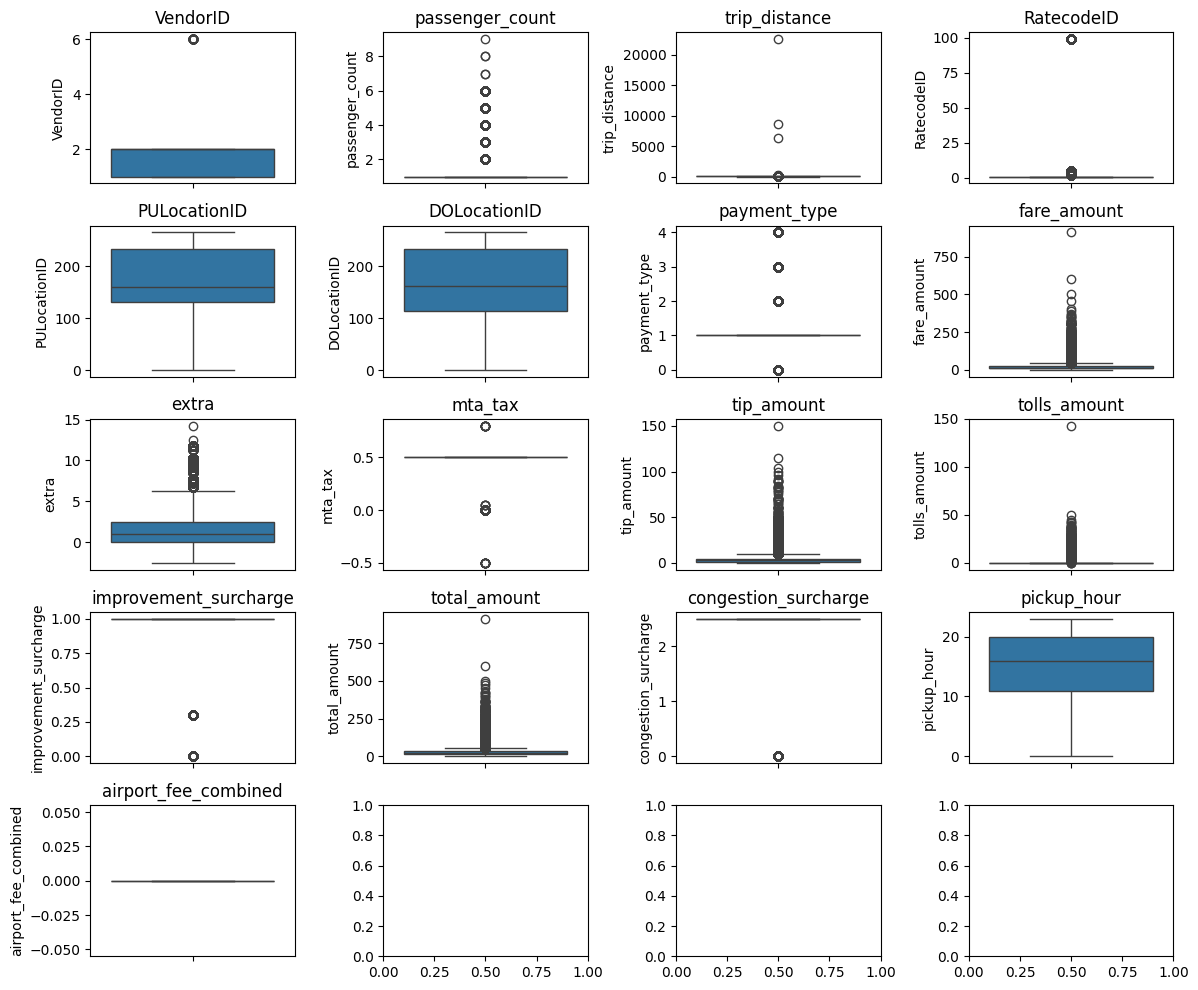

In [ ]:
fig, axes = plt.subplots(5, 4, figsize=(12, 10))

axes = axes.flatten()

for i, col in enumerate(numeric_cols[:len(axes)]):
  sns.boxplot(y=df[col], ax=axes[i])
  axes[i].set_title(col)

plt.tight_layout()
plt.show()

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [ ]:
# remove passenger_count > 6
df['passenger_count'].value_counts()

,count
passenger_count,
1.0,221618
2.0,42090
3.0,10564
4.0,5813
5.0,3505
6.0,2378
8.0,2
7.0,2
9.0,1


In [ ]:
df = df[df['passenger_count'] <= 6]

In [ ]:
df['passenger_count'].value_counts()

,count
passenger_count,
1.0,221618
2.0,42090
3.0,10564
4.0,5813
5.0,3505
6.0,2378


In [ ]:
# Continue with outlier handling

Entries where trip_distance is nearly 0 and fare_amount is more than 300

In [ ]:
df[(df['trip_distance'] < 0.1) & (df['fare_amount'] > 300)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,pickup_hour,pickup_date,airport_fee_combined
26687,1,2023-02-09 07:37:30,2023-02-09 07:39:13,1.0,0.0,5.0,246,246,4,910.0,0.0,0.0,0.0,0.0,1.0,911.0,0.0,7,2023-02-09,0.0
47395,2,2023-04-05 21:16:43,2023-04-05 21:25:57,1.0,0.0,5.0,265,265,2,600.0,0.0,0.0,0.0,0.0,1.0,601.0,0.0,21,2023-04-05,0.0
208309,2,2023-06-21 12:05:21,2023-06-21 12:05:42,1.0,0.0,5.0,265,265,2,500.0,0.0,0.0,0.0,0.0,1.0,501.0,0.0,12,2023-06-21,0.0
215746,2,2023-06-29 20:56:07,2023-06-29 20:56:15,1.0,0.0,5.0,265,265,1,350.0,0.0,0.0,70.2,0.0,1.0,421.2,0.0,20,2023-06-29,0.0
223371,2,2023-12-07 23:39:43,2023-12-07 23:39:59,1.0,0.0,5.0,265,265,2,319.0,0.0,0.0,0.0,0.0,1.0,320.0,0.0,23,2023-12-07,0.0


In [ ]:
df = df[~((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300))]

In [ ]:
df[(df['trip_distance'] < 0.1) & (df['fare_amount'] > 300)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,pickup_hour,pickup_date,airport_fee_combined


Entries where trip_distance and fare_amount are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)

In [ ]:
df[(df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID'])]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,pickup_hour,pickup_date,airport_fee_combined
20512,1,2023-02-01 08:20:36,2023-02-01 08:20:36,6.0,0.0,99.0,145,264,2,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,8,2023-02-01,0.0
20833,2,2023-02-01 16:53:34,2023-02-01 16:54:13,1.0,0.0,1.0,193,7,1,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,16,2023-02-01,0.0
234646,1,2023-12-20 13:40:27,2023-12-20 13:40:27,1.0,0.0,5.0,138,264,2,0.0,9.25,0.0,0.0,0.0,1.0,10.25,2.5,13,2023-12-20,0.0
238228,1,2023-12-27 20:51:43,2023-12-27 21:00:02,3.0,0.0,5.0,132,215,4,0.0,1.75,0.0,0.0,0.0,1.0,2.75,0.0,20,2023-12-27,0.0


In [ ]:
condition = (df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID'])
rows_index = df[condition].index

In [ ]:
df.loc[condition, 'trip_distance'] = df['trip_distance'].median()
df.loc[condition, 'fare_amount'] = df['fare_amount'].median()

In [ ]:
df.loc[rows_index, ['PULocationID', 'DOLocationID', 'trip_distance', 'fare_amount']]


,PULocationID,DOLocationID,trip_distance,fare_amount
20512,145,264,1.81,13.5
20833,193,7,1.81,13.5
234646,138,264,1.81,13.5
238228,132,215,1.81,13.5


Entries where trip_distance is more than 250 miles.

In [ ]:
df[df['trip_distance'] > 250]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,pickup_hour,pickup_date,airport_fee_combined
33366,2,2023-02-17 07:17:00,2023-02-17 07:25:00,1.0,8645.77,1.0,238,230,0,13.34,0.0,0.5,4.34,0.0,1.0,21.68,0.0,7,2023-02-17,0.0
36152,2,2023-02-19 22:06:00,2023-02-19 22:22:00,1.0,6284.45,1.0,186,236,0,16.00,0.0,0.5,0.00,0.0,1.0,20.00,0.0,22,2023-02-19,0.0
202120,2,2023-06-13 09:59:00,2023-06-13 10:12:00,1.0,22528.82,1.0,116,239,0,17.42,0.0,0.5,0.37,0.0,1.0,21.79,0.0,9,2023-06-13,0.0


In [ ]:
condition = (df['trip_distance'] > 250)
rows_index = df[condition].index

In [ ]:
df.loc[condition, 'trip_distance'] = df['trip_distance'].median()

In [ ]:
df.loc[rows_index]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,pickup_hour,pickup_date,airport_fee_combined
33366,2,2023-02-17 07:17:00,2023-02-17 07:25:00,1.0,1.81,1.0,238,230,0,13.34,0.0,0.5,4.34,0.0,1.0,21.68,0.0,7,2023-02-17,0.0
36152,2,2023-02-19 22:06:00,2023-02-19 22:22:00,1.0,1.81,1.0,186,236,0,16.00,0.0,0.5,0.00,0.0,1.0,20.00,0.0,22,2023-02-19,0.0
202120,2,2023-06-13 09:59:00,2023-06-13 10:12:00,1.0,1.81,1.0,116,239,0,17.42,0.0,0.5,0.37,0.0,1.0,21.79,0.0,9,2023-06-13,0.0


Entries where payment_type is 0 (there is no payment_type 0 defined in the data dictionary)

In [ ]:
df['payment_type'].value_counts()

,count
payment_type,
1,225150
2,47747
0,9566
4,2139
3,1361


In [ ]:
df = df[~(df['payment_type'] == 0)]

In [ ]:
df['payment_type'].value_counts()

,count
payment_type,
1,225150
2,47747
4,2139
3,1361


In [ ]:
# Do any columns need standardising?


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [ ]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'pickup_hour',
 'pickup_date',
 'airport_fee_combined']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical? -numerical


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

In [ ]:
categorical_cols = ['VendorID', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type', 'pickup_hour']

numerical_cols = ['passenger_count', 'trip_distance', 'trip_duration']

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [ ]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month

In [ ]:
# Find and show the hourly trends in taxi pickups
pickup_hour = df['pickup_hour'].value_counts().sort_index()
pickup_hour

,count
pickup_hour,
0,7167
1,4830
2,3147
3,2049
4,1345
5,1384
6,3380
7,6889
8,9564


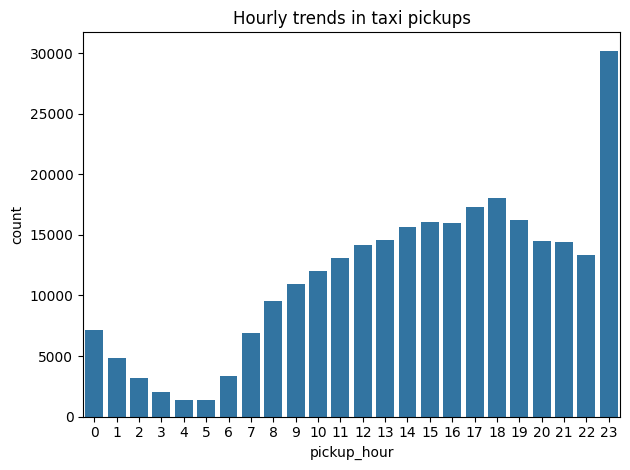

In [ ]:
sns.countplot(x='pickup_hour', data=df)

plt.title('Hourly trends in taxi pickups')
plt.tight_layout()
plt.show()

In [ ]:
# Find and show the daily trends in taxi pickups (days of the week)

df['pickup_day'].value_counts()


,count
pickup_day,
Wednesday,43118
Thursday,43065
Saturday,41245
Friday,40461
Tuesday,39620
Monday,34479
Sunday,34409


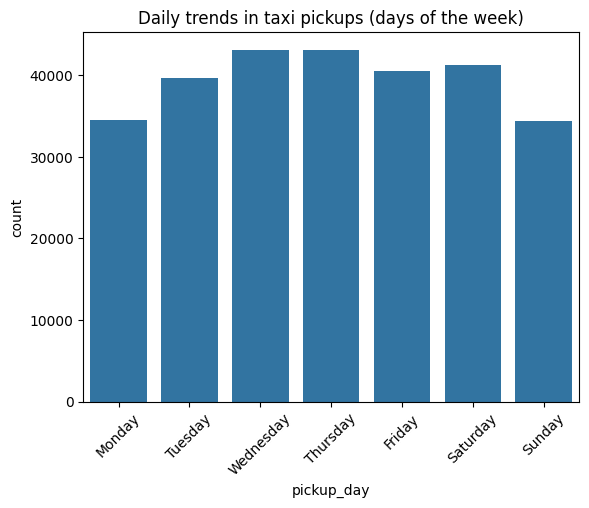

In [ ]:
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

sns.countplot(x='pickup_day', data=df, order=day_order)

plt.title('Daily trends in taxi pickups (days of the week)')
plt.xticks(rotation=45)
plt.show()

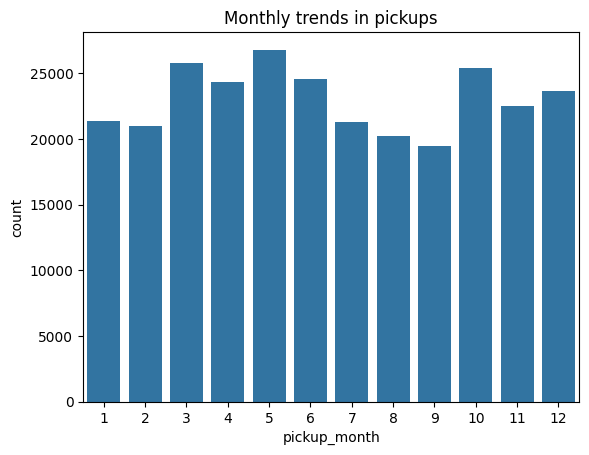

In [ ]:
# Show the monthly trends in pickups
sns.countplot(x='pickup_month', data=df)

plt.title('Monthly trends in pickups')
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [ ]:
# Analyse the above parameters - zero values because the minimum is zero

df[['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']].describe()


,fare_amount,tip_amount,total_amount,trip_distance
count,276397.000000,276397.000000,276397.000000,276397.000000
mean,19.914837,3.597881,29.082680,3.514487
std,18.233970,4.072739,22.842128,4.582903
min,0.000000,0.000000,0.000000,0.000000
25%,9.300000,1.000000,15.960000,1.070000
50%,13.500000,2.860000,21.000000,1.800000
75%,21.900000,4.480000,31.080000,3.480000
max,455.200000,150.290000,488.700000,187.350000


In [ ]:
cols = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']
(df[cols] == 0).sum()

,0
fare_amount,85
tip_amount,61955
total_amount,42
trip_distance,3415


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

Yes, tip_amount can be zero but other financial parameters for e.g fare_amount and total_amount should not be zero

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [ ]:
# Create a df with non zero entries for the selected parameters.
clean_df = df[(df['fare_amount'] > 0) &
              (df['tip_amount'] >= 0) &
              (df['total_amount'] > 0) &
              ~((df['trip_distance'] == 0) & (df['PULocationID'] != df['DOLocationID']))
].copy()

In [ ]:
clean_df[['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']].describe()

,fare_amount,tip_amount,total_amount,trip_distance
count,275169.000000,275169.000000,275169.000000,275169.000000
mean,19.894009,3.603782,29.071901,3.528900
std,18.192973,4.061177,22.811132,4.584212
min,0.010000,0.000000,1.010000,0.000000
25%,9.300000,1.000000,15.960000,1.080000
50%,13.500000,2.860000,21.000000,1.810000
75%,21.900000,4.500000,31.080000,3.490000
max,455.200000,150.290000,488.700000,187.350000


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

In [ ]:
clean_df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID',
       'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'pickup_hour', 'pickup_date',
       'airport_fee_combined', 'pickup_day', 'pickup_month'],
      dtype='object')

pickup_month
1     585877.50
2     572959.57
3     729825.67
4     706613.59
5     786641.97
6     722191.67
7     625481.18
8     590117.34
9     585193.19
10    762094.46
11    649644.55
12    683045.25
Name: total_amount, dtype: float64


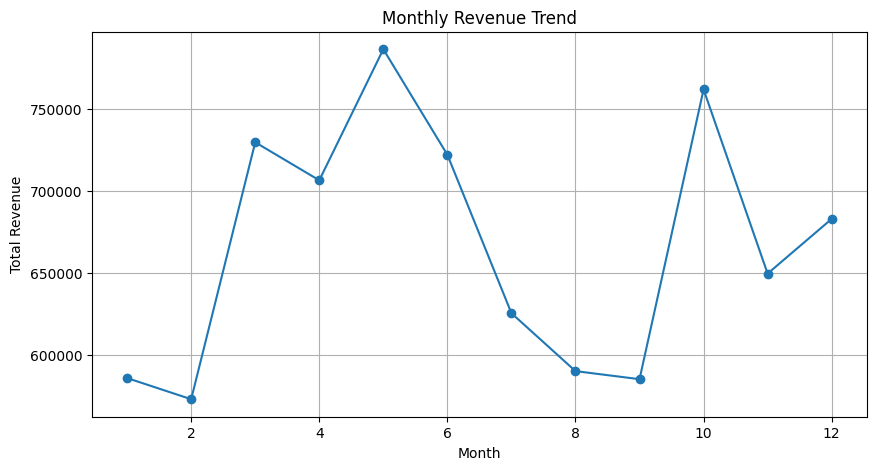

In [ ]:
# Group data by month and analyse monthly revenue
monthly_revenue = clean_df.groupby('pickup_month')['total_amount'].sum()
print(monthly_revenue)

plt.figure(figsize=(10,5))

monthly_revenue.plot(marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [ ]:
# Calculate proportion of each quarter
clean_df['quarter'] = clean_df['tpep_pickup_datetime'].dt.quarter

In [ ]:
quarter_revenue = clean_df.groupby('quarter')['total_amount'].sum()
quarter_revenue

,total_amount
quarter,
1,1888662.74
2,2215447.23
3,1800791.71
4,2094784.26


In [ ]:
each_quarter_proportion = quarter_revenue/quarter_revenue.sum() * 100
each_quarter_proportion

,total_amount
quarter,
1,23.609211
2,27.694178
3,22.510780
4,26.185831


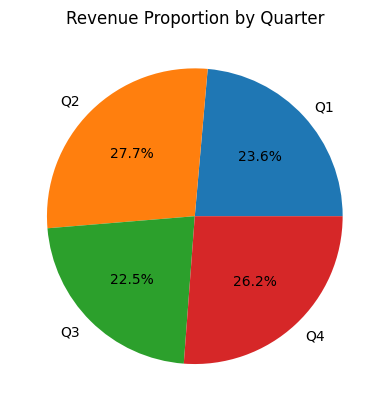

In [ ]:
plt.pie(each_quarter_proportion,
        labels=['Q1', 'Q2', 'Q3', 'Q4'],
        autopct='%1.1f%%')

plt.title('Revenue Proportion by Quarter')

plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

In [ ]:
# Show how trip fare is affected by distance

corr = clean_df[clean_df['trip_distance'] > 0][['trip_distance', 'fare_amount']].corr()
corr

,trip_distance,fare_amount
trip_distance,1.000000,0.944725
fare_amount,0.944725,1.000000


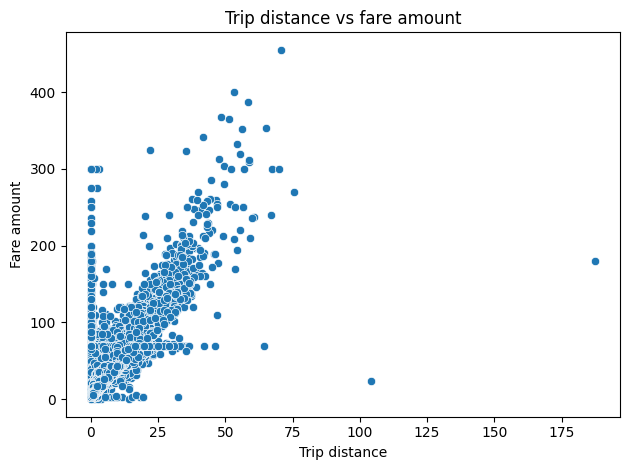

In [ ]:
sns.scatterplot(data=clean_df, x='trip_distance', y='fare_amount')

plt.title('Trip distance vs fare amount')
plt.xlabel('Trip distance')
plt.ylabel('Fare amount')
plt.tight_layout()
plt.show()

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [ ]:
# Show relationship between fare and trip duration
clean_df['trip_duration'] = (clean_df['tpep_dropoff_datetime'] - clean_df['tpep_pickup_datetime']).dt.total_seconds() / 60

In [ ]:
clean_df['trip_duration']

,trip_duration
1,2.483333
2,44.583333
3,38.116667
4,6.300000
5,13.416667
...,...
285967,6.816667
285968,4.233333
285969,28.150000
285970,23.783333


In [ ]:
clean_df['fare_amount'].corr(clean_df['trip_duration'])

np.float64(0.25365986576190463)

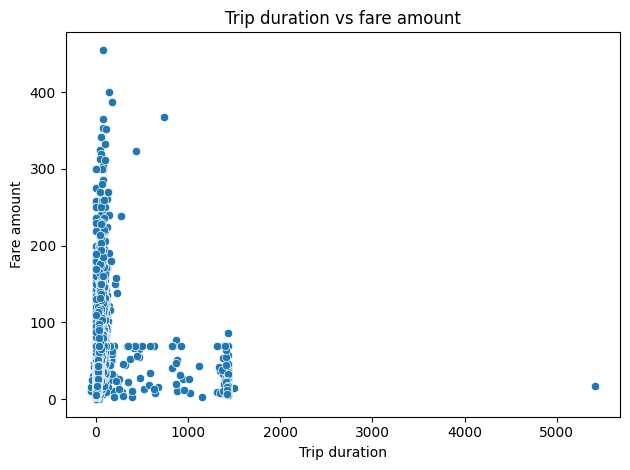

In [ ]:
sns.scatterplot(data=clean_df, x='trip_duration', y='fare_amount')

plt.title('Trip duration vs fare amount')
plt.xlabel('Trip duration')
plt.ylabel('Fare amount')
plt.tight_layout()
plt.show()

In [ ]:
# Show relationship between fare and number of passengers
clean_df['fare_amount'].corr(clean_df['passenger_count'])


np.float64(0.038061618521075265)

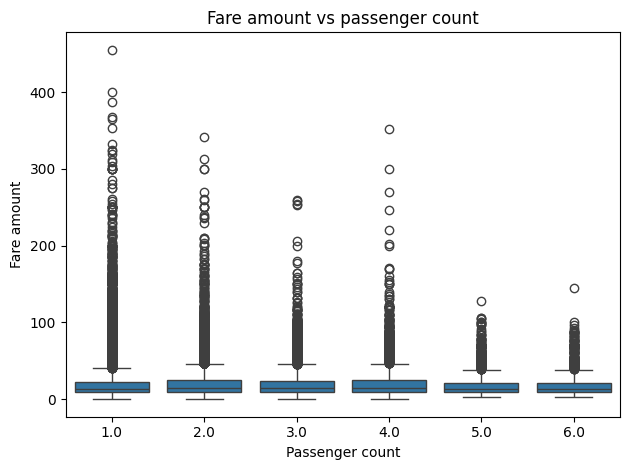

In [ ]:
sns.boxplot(data=clean_df, x='passenger_count', y='fare_amount')

plt.title('Fare amount vs passenger count')
plt.xlabel('Passenger count')
plt.ylabel('Fare amount')
plt.tight_layout()
plt.show()

In [ ]:
# Show relationship between tip and trip distance

clean_df['tip_amount'].corr(clean_df['trip_distance'])

np.float64(0.5788779006114955)

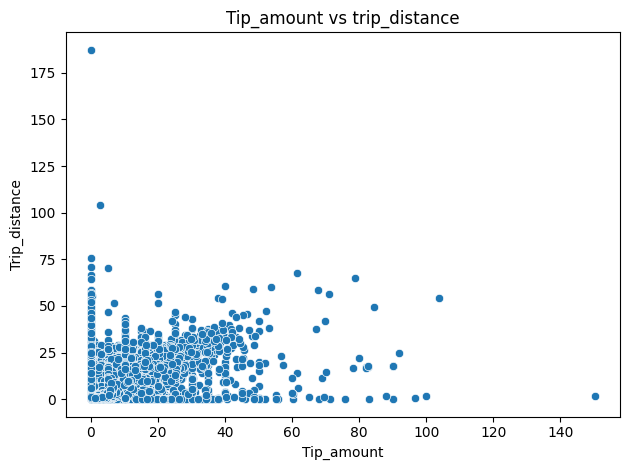

In [ ]:
sns.scatterplot(data=clean_df, x='tip_amount', y='trip_distance')

plt.title('Tip_amount vs trip_distance')
plt.xlabel('Tip_amount')
plt.ylabel('Trip_distance')
plt.tight_layout()
plt.show()

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

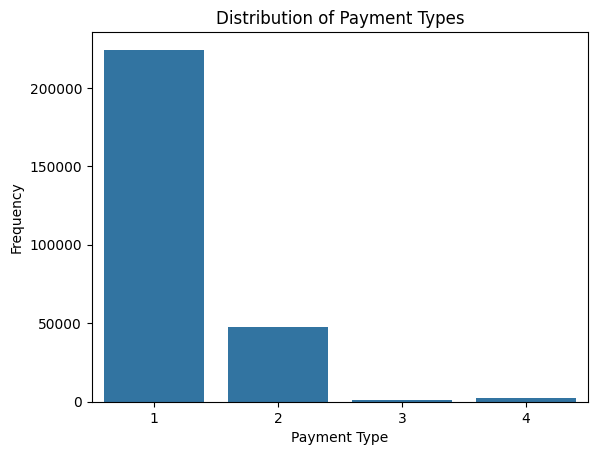

In [ ]:
# Analyse the distribution of different payment types (payment_type).

sns.countplot(
    data=clean_df,
    x='payment_type'
)

plt.title('Distribution of Payment Types')
plt.xlabel('Payment Type')
plt.ylabel('Frequency')

plt.show()



- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [ ]:
import geopandas as gpd


# Read the shapefile using geopandas
zones = gpd.read_file('/content/drive/MyDrive/Upgrad/EDA/EDA_projects/Datasets and Dictionary/taxi_zones/taxi_zones.shp')
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

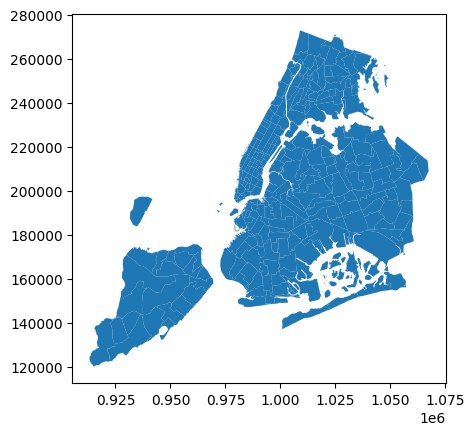

In [ ]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [ ]:
# Merge zones and trip records using locationID and PULocationID
total_df = clean_df.merge(zones, left_on='PULocationID', right_on='LocationID')


In [ ]:
total_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272407 entries, 0 to 272406
Data columns (total 31 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               272407 non-null  int64         
 1   tpep_pickup_datetime   272407 non-null  datetime64[us]
 2   tpep_dropoff_datetime  272407 non-null  datetime64[us]
 3   passenger_count        272407 non-null  float64       
 4   trip_distance          272407 non-null  float64       
 5   RatecodeID             272407 non-null  float64       
 6   PULocationID           272407 non-null  int64         
 7   DOLocationID           272407 non-null  int64         
 8   payment_type           272407 non-null  int64         
 9   fare_amount            272407 non-null  float64       
 10  extra                  272407 non-null  float64       
 11  mta_tax                272407 non-null  float64       
 12  tip_amount             272407 non-null  floa

In [ ]:
total_df['zone'].value_counts()

,count
zone,
JFK Airport,15453
Upper East Side South,12720
Midtown Center,12702
Upper East Side North,11156
LaGuardia Airport,10054
...,...
South Beach/Dongan Hills,1
Port Richmond,1
City Island,1


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [ ]:
# Group data by location and calculate the number of trips
trips_group_by_location = total_df.groupby('LocationID').size().reset_index(name='total_trips')
trips_group_by_location

,LocationID,total_trips
0,1,35
1,3,8
2,4,278
3,5,1
4,6,3
...,...,...
230,259,3
231,260,44
232,261,1447
233,262,3309


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [ ]:
# Merge trip counts back to the zones GeoDataFrame
geo_df = total_df.merge(trips_group_by_location, on='LocationID', how='left')
geo_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272407 entries, 0 to 272406
Data columns (total 31 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               272407 non-null  int64         
 1   tpep_pickup_datetime   272407 non-null  datetime64[us]
 2   tpep_dropoff_datetime  272407 non-null  datetime64[us]
 3   passenger_count        272407 non-null  float64       
 4   trip_distance          272407 non-null  float64       
 5   RatecodeID             272407 non-null  float64       
 6   PULocationID           272407 non-null  int64         
 7   DOLocationID           272407 non-null  int64         
 8   payment_type           272407 non-null  int64         
 9   fare_amount            272407 non-null  float64       
 10  extra                  272407 non-null  float64       
 11  mta_tax                272407 non-null  float64       
 12  tip_amount             272407 non-null  floa

The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

In [ ]:
type(geo_df)

pandas.core.frame.DataFrame

In [ ]:
geo_df = gpd.GeoDataFrame(geo_df, geometry='geometry')

In [ ]:
type(geo_df)

geopandas.geodataframe.GeoDataFrame

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

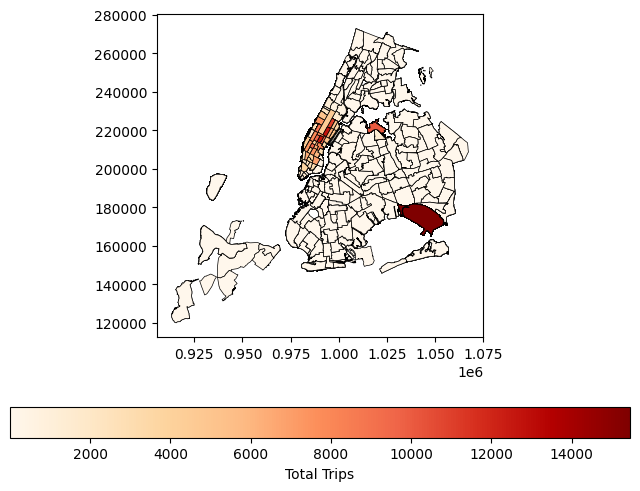

In [ ]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot the map and display it
geo_df.plot(column='total_trips',
            ax=ax,
            cmap='OrRd',
            edgecolor='black',
            linewidth=0.5,
            legend=True,
            legend_kwds={'label': 'Total Trips', 'orientation': 'horizontal'})
plt.show()

In [ ]:
# can you try displaying the zones DF sorted by the number of trips?

trips_sorted = geo_df.sort_values(by='total_trips', ascending=False)
trips_sorted.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,quarter,trip_duration,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,total_trips
1,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,132,163,1,70.0,...,3,44.583333,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",15453
138463,2,2023-05-05 08:49:35,2023-05-05 09:49:49,1.0,19.91,2.0,132,151,2,70.0,...,2,60.233333,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",15453
138476,2,2023-05-05 09:51:02,2023-05-05 10:26:06,1.0,12.07,1.0,132,61,1,49.9,...,2,35.066667,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",15453
49,1,2023-09-01 06:25:53,2023-09-01 06:38:05,3.0,3.80,1.0,132,216,2,18.4,...,3,12.200000,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",15453
272386,1,2023-11-30 23:11:21,2023-11-30 23:45:23,1.0,19.80,2.0,132,151,1,70.0,...,4,34.033333,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",15453


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [ ]:
# Find routes which have the slowest speeds at different times of the day

# Calculating trip duration per hour
clean_df['tpep_pickup_datetime'] = pd.to_datetime(clean_df['tpep_pickup_datetime'])
clean_df['tpep_dropoff_datetime'] = pd.to_datetime(clean_df['tpep_dropoff_datetime'])

clean_df['trip_duration_hr'] = (clean_df['tpep_dropoff_datetime'] - clean_df['tpep_pickup_datetime']).dt.total_seconds() / 3600

In [ ]:
clean_df['trip_duration_hr']

,trip_duration_hr
1,0.041389
2,0.743056
3,0.635278
4,0.105000
5,0.223611
...,...
285967,0.113611
285968,0.070556
285969,0.469167
285970,0.396389


In [ ]:
# Determing the route

clean_df['route'] = clean_df['PULocationID'].astype(str) + '-' + clean_df['DOLocationID'].astype(str)

In [ ]:
clean_df['route']

,route
1,142-142
2,132-163
3,249-180
4,144-232
5,79-263
...,...
285967,4-79
285968,263-237
285969,230-223
285970,186-65


In [ ]:
# calculating average distance and duration by hour
route_by_hour = clean_df.groupby(['route', 'pickup_hour']).agg(
    avg_distance=('trip_distance', 'mean'),
    avg_duration=('trip_duration_hr', 'mean')
).reset_index()

In [ ]:
route_by_hour

,route,pickup_hour,avg_distance,avg_duration
0,1-1,5,0.000000,0.004028
1,1-1,6,0.003333,0.011019
2,1-1,7,0.000000,0.003472
3,1-1,8,0.000000,0.002222
4,1-1,9,0.000000,0.005000
...,...,...,...,...
60388,97-97,22,19.460000,0.727222
60389,98-135,12,2.000000,0.158889
60390,98-226,10,8.900000,0.417222
60391,98-29,9,14.600000,0.555278


In [ ]:
# Filtering out the noisy values
route_by_hour = route_by_hour[
    (route_by_hour['avg_distance'] > 0) &
    (route_by_hour['avg_duration'] > 0)
]

In [ ]:
# calculating average speed
route_by_hour['avg_speed'] = (route_by_hour['avg_distance'] / route_by_hour['avg_duration'])

In [ ]:
# Identifying slower routes
slow_routes = route_by_hour.sort_values(by='avg_speed', ascending=True).head(10)
slow_routes

,route,pickup_hour,avg_distance,avg_duration,avg_speed
2601,113-113,13,0.200000,7.958796,0.025129
30018,193-193,10,0.000667,0.025315,0.026335
31927,226-145,18,1.200000,45.165000,0.026569
45667,260-129,17,0.960000,23.560556,0.040746
48400,264-237,15,0.040000,0.929444,0.043036
30376,209-232,13,1.040000,23.864722,0.043579
3166,113-235,22,0.280000,5.820556,0.048105
52714,50-43,8,1.420000,23.855556,0.059525
25069,164-100,21,0.790000,11.647222,0.067827
9703,134-265,15,0.100000,1.354444,0.073831


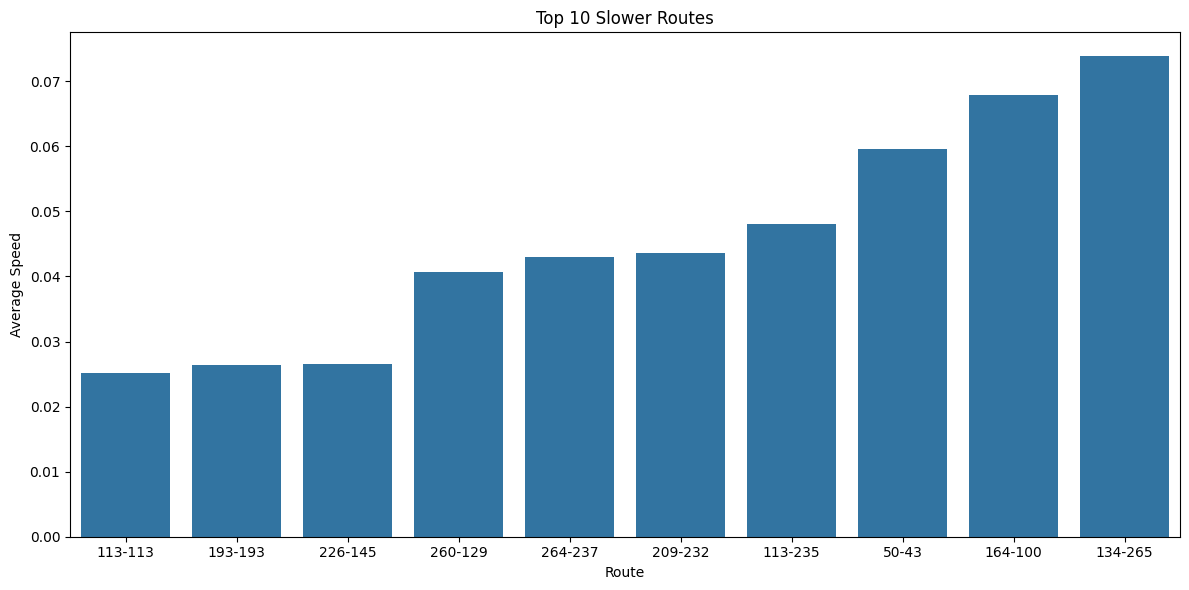

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(data=slow_routes, x='route', y='avg_speed')

plt.title('Top 10 Slower Routes')
plt.xlabel('Route')
plt.ylabel('Average Speed')
plt.tight_layout()
plt.show()

How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [ ]:
# Visualise the number of trips per hour and find the busiest hour

# Number of trips per hour

trips_per_hour = clean_df.groupby('pickup_hour').size().reset_index(name='number_of_trips')
trips_per_hour

,pickup_hour,number_of_trips
0,0,7136
1,1,4813
2,2,3135
3,3,2040
4,4,1325
5,5,1369
6,6,3350
7,7,6851
8,8,9509
9,9,10923


In [ ]:
# Busiest hour

busiest_hour = trips_per_hour.loc[trips_per_hour['number_of_trips'].idxmax()]
busiest_hour

,23
pickup_hour,23
number_of_trips,30099


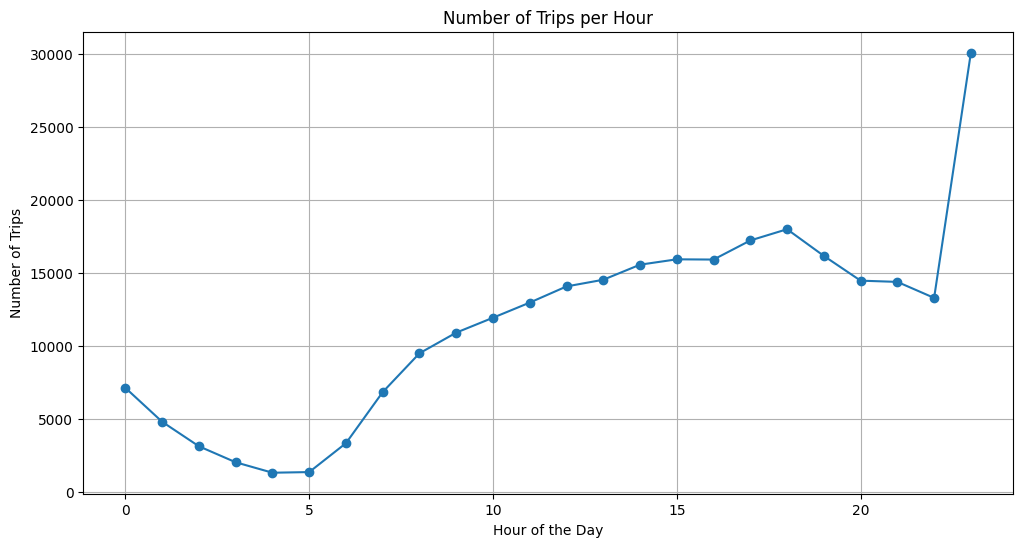

In [ ]:
# Visualization
plt.figure(figsize=(12,6))

plt.plot(trips_per_hour['pickup_hour'], trips_per_hour['number_of_trips'], marker='o')

plt.title('Number of Trips per Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.grid(True)
plt.show()

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [ ]:
# Scale up the number of trips
# Fill in the value of your sampling fraction and use that to scale up the numbers

sampling_frac = 0.007
trips_per_hour['actual_trips'] = (trips_per_hour['number_of_trips'] / sampling_frac)
trips_per_hour.sort_values(by='actual_trips', ascending=False).head()

,pickup_hour,number_of_trips,actual_trips
23,23,30099,4.299857e+06
18,18,18007,2.572429e+06
17,17,17238,2.462571e+06
19,19,16179,2.311286e+06
15,15,15945,2.277857e+06


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

In [ ]:
# Compare traffic trends for the week days and weekends
clean_df['tpep_pickup_datetime'] = pd.to_datetime(clean_df['tpep_pickup_datetime'])
clean_df['day_of_week'] = clean_df['tpep_pickup_datetime'].dt.dayofweek
clean_df['day_of_week']

,day_of_week
1,4
2,4
3,4
4,4
5,4
...,...
285967,3
285968,3
285969,3
285970,3


In [ ]:
# Creating weekdays vs weekends
clean_df['day_type'] = clean_df['day_of_week'].apply(lambda x: 'weekend' if x >= 5 else 'weekday')
clean_df['day_type']

,day_type
1,weekday
2,weekday
3,weekday
4,weekday
5,weekday
...,...
285967,weekday
285968,weekday
285969,weekday
285970,weekday


In [ ]:
# Compare hourly traffic pattern on weekdays
hourly_pattren = clean_df.groupby(['day_type','pickup_hour']).size().reset_index(name='number_of_trips')
hourly_pattren.head()

,day_type,pickup_hour,number_of_trips
0,weekday,0,3564
1,weekday,1,1805
2,weekday,2,975
3,weekday,3,605
4,weekday,4,568


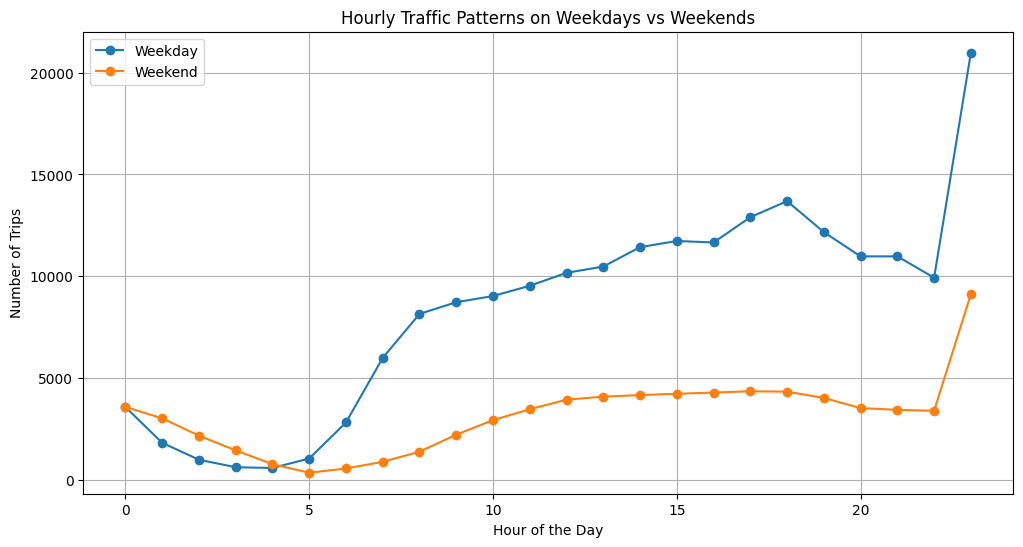

In [ ]:
weekday_data = hourly_pattren[hourly_pattren['day_type'] == 'weekday']
weekend_data = hourly_pattren[hourly_pattren['day_type'] == 'weekend']

plt.figure(figsize=(12, 6))

plt.plot(weekday_data['pickup_hour'], weekday_data['number_of_trips'], marker='o', label='Weekday')
plt.plot(weekend_data['pickup_hour'], weekend_data['number_of_trips'], marker='o', label='Weekend')

plt.grid(True)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.title('Hourly Traffic Patterns on Weekdays vs Weekends')
plt.legend()
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [ ]:
# Find top 10 pickup and dropoff zones

# Top 10 pickup zones overall
top_pickup_zones = clean_df.groupby('PULocationID').size().sort_values(ascending=False).head(10).index
print(top_pickup_zones)

# Hourly pickup trend for those zones
pickup_trends = clean_df[clean_df['PULocationID'].isin(top_pickup_zones)].groupby(['PULocationID', 'pickup_hour']).size().reset_index(name='pickup_count')
pickup_trends.head(24)

Index([132, 237, 161, 236, 138, 162, 186, 230, 142, 170], dtype='int64', name='PULocationID')


,PULocationID,pickup_hour,pickup_count
0,132,0,548
1,132,1,241
2,132,2,78
3,132,3,52
4,132,4,48
5,132,5,159
6,132,6,409
7,132,7,441
8,132,8,356
9,132,9,318


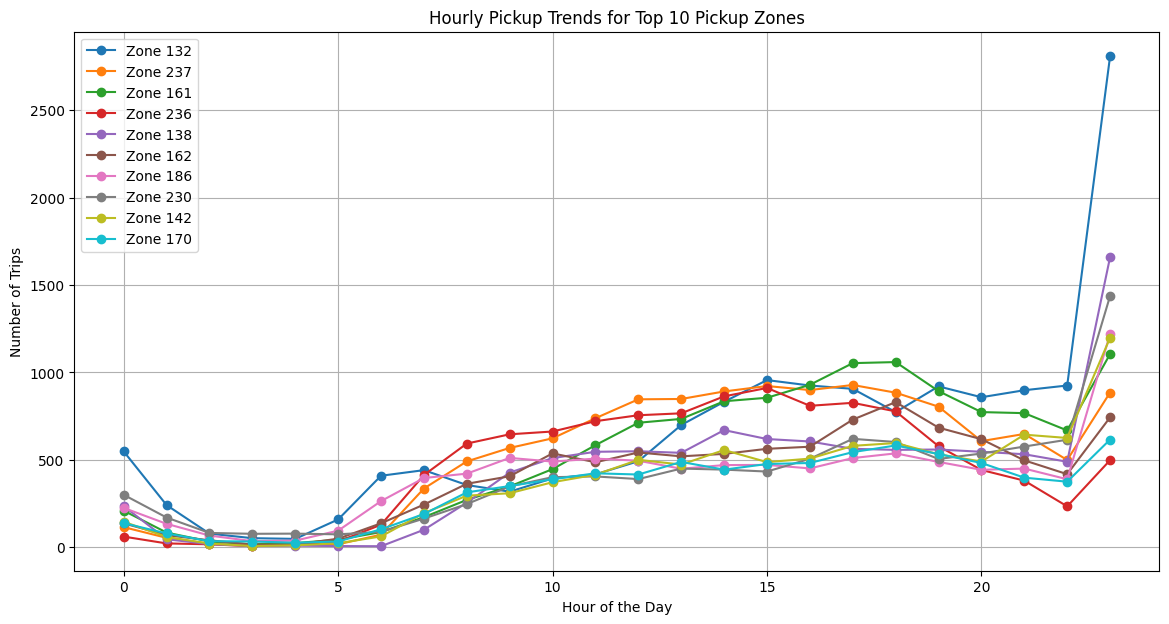

In [ ]:
plt.figure(figsize=(14, 7))

for zone in top_pickup_zones:
    zone_data = pickup_trends[pickup_trends['PULocationID'] == zone]
    plt.plot(zone_data['pickup_hour'], zone_data['pickup_count'], marker='o', label=f'Zone {zone}')

plt.grid(True)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.title('Hourly Pickup Trends for Top 10 Pickup Zones')
plt.legend()
plt.show()

In [ ]:
# Top 10 dropoff zones
top_dropoff_zones = clean_df.groupby('DOLocationID').size().sort_values(ascending=False).head(10).index

dropoff_trends = clean_df[clean_df['DOLocationID'].isin(top_dropoff_zones)].groupby(['DOLocationID', 'pickup_hour']).size().reset_index(name='dropoff_count')
dropoff_trends.head(24)

,DOLocationID,pickup_hour,dropoff_count
0,68,0,195
1,68,1,130
2,68,2,90
3,68,3,68
4,68,4,31
5,68,5,37
6,68,6,96
7,68,7,183
8,68,8,252
9,68,9,302


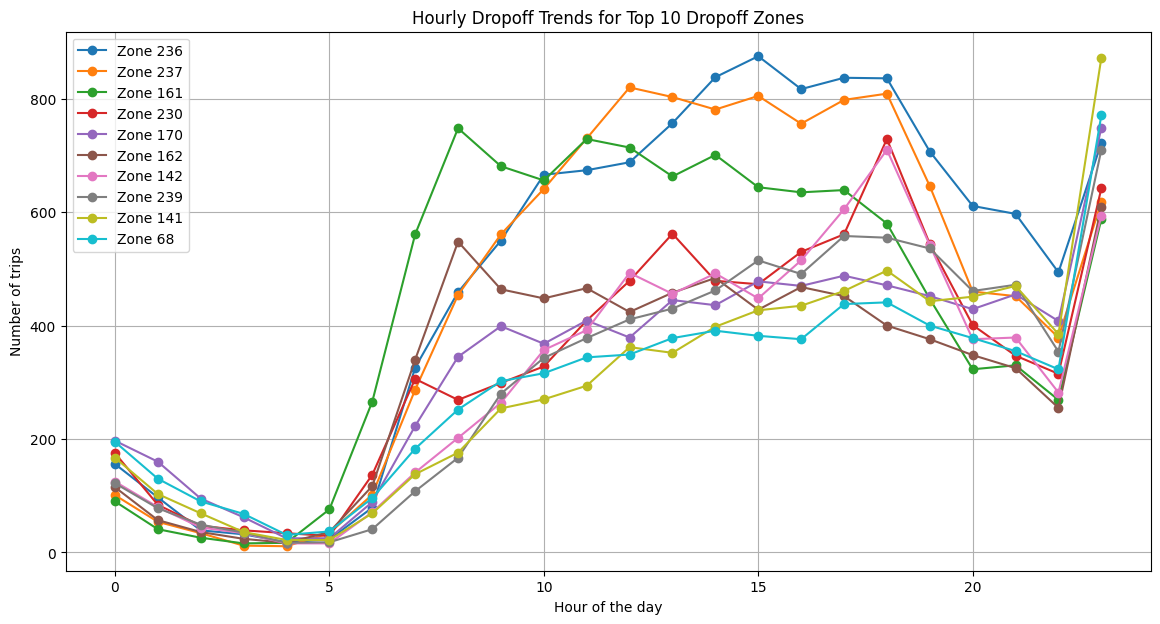

In [ ]:
plt.figure(figsize=(14, 7))

for zone in top_dropoff_zones:
    zone_data = dropoff_trends[dropoff_trends['DOLocationID'] == zone]
    plt.plot(zone_data['pickup_hour'], zone_data['dropoff_count'], marker='o', label=f'Zone {zone}')

plt.grid(True)
plt.xlabel('Hour of the day')
plt.ylabel('Number of trips')
plt.title('Hourly Dropoff Trends for Top 10 Dropoff Zones')
plt.legend()
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [ ]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
# Pickup counts
pickup_counts = clean_df.groupby('PULocationID').size().reset_index(name='pickup_count')

# Dropoff counts
dropoff_counts = clean_df.groupby('DOLocationID').size().reset_index(name='dropoff_count')

In [ ]:
zone_counts = pickup_counts.merge(dropoff_counts, left_on='PULocationID', right_on='DOLocationID', how='outer')

In [ ]:
zone_counts.isna().sum()

,0
PULocationID,17
pickup_count,17
DOLocationID,0
dropoff_count,0


In [ ]:
# Fill in missing values
zone_counts.fillna(0, inplace=True)

In [ ]:
zone_counts.isna().sum()

,0
PULocationID,0
pickup_count,0
DOLocationID,0
dropoff_count,0


In [ ]:
zone_counts = zone_counts[(zone_counts['pickup_count'] > 0) &
                          (zone_counts['dropoff_count'] > 0)]

In [ ]:
# Calculating the pickup and drop off ratio
zone_counts['pickup_dropoff_ratio'] = (zone_counts['pickup_count'] / zone_counts['dropoff_count'])

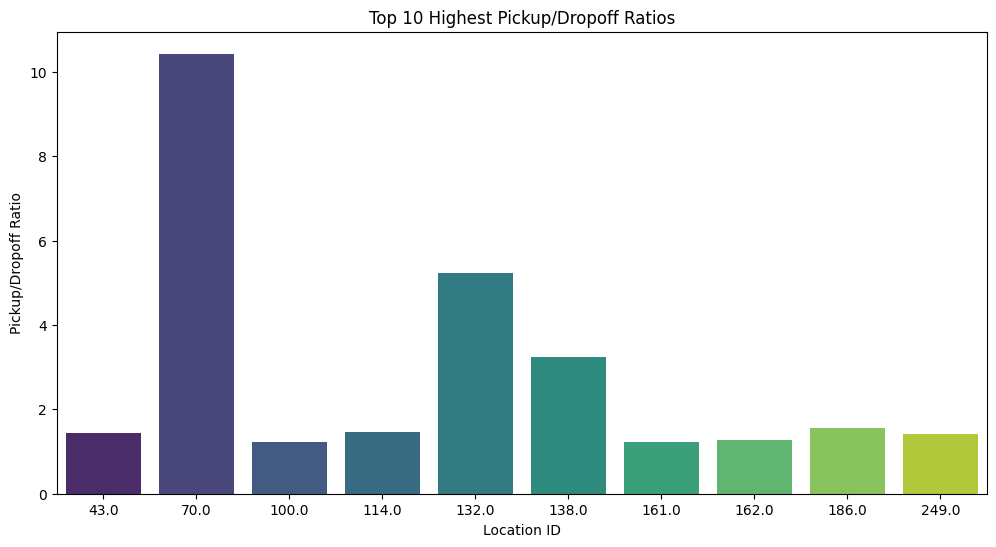

In [ ]:
# Top 10 highest ratios
top_zone = zone_counts.sort_values(by='pickup_dropoff_ratio', ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(data=top_zone, x='PULocationID', y='pickup_dropoff_ratio', palette='viridis')

plt.title('Top 10 Highest Pickup/Dropoff Ratios')
plt.xlabel('Location ID')
plt.ylabel('Pickup/Dropoff Ratio')
plt.show()

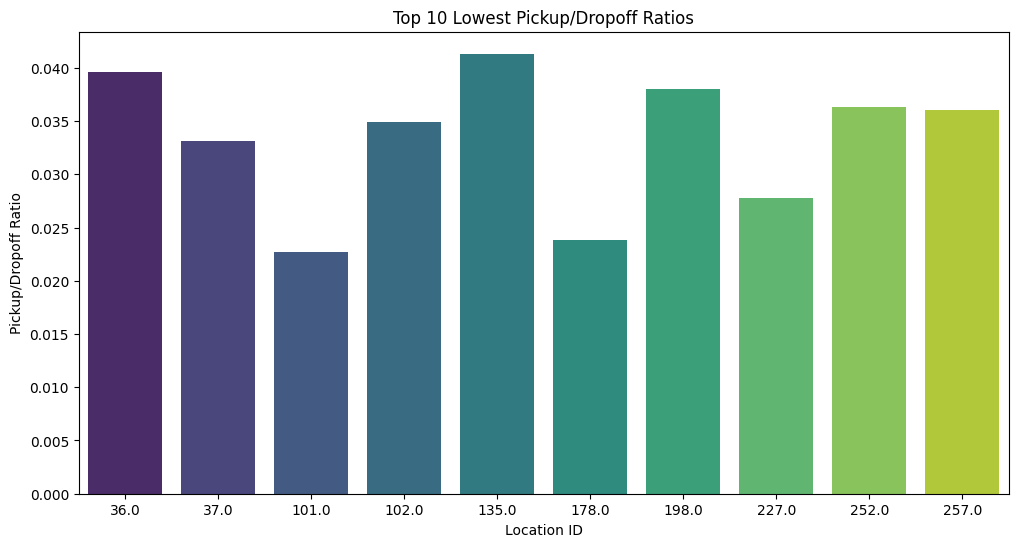

In [ ]:
# Top 10 lowest ratios
lowest_zones = zone_counts.sort_values(by='pickup_dropoff_ratio', ascending=True).head(10)
plt.figure(figsize=(12,6))

sns.barplot(data=lowest_zones, x='PULocationID', y='pickup_dropoff_ratio', palette='viridis')

plt.title('Top 10 Lowest Pickup/Dropoff Ratios')
plt.xlabel('Location ID')
plt.ylabel('Pickup/Dropoff Ratio')
plt.show()

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [ ]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

# Filter trips during night hours
night_df = clean_df[clean_df['pickup_hour'].isin([23, 0, 1, 2, 3, 4, 5])]
# Zones with higher night hour pickup
night_pickups = night_df.groupby(['PULocationID', 'pickup_hour']).size().reset_index(name='night_pickup_counts').sort_values(by='night_pickup_counts', ascending=False).head(10)
night_pickups

,PULocationID,pickup_hour,night_pickup_counts
309,132,23,2808
327,138,23,1659
566,230,23,1437
109,48,23,1398
182,79,23,1389
480,186,23,1220
348,142,23,1198
419,161,23,1105
649,249,23,1104
610,237,23,885


In [ ]:
# Zones with higher night hour pickup
night_df.groupby(['DOLocationID', 'pickup_hour']).size().reset_index(name='night_dropoff_counts').sort_values(by='night_dropoff_counts', ascending=False).head(10)

,DOLocationID,pickup_hour,night_dropoff_counts
338,79,23,919
611,141,23,872
460,107,23,853
1211,263,23,814
285,68,23,771
770,170,23,749
1074,236,23,722
1095,239,23,710
1027,229,23,667
738,164,23,666


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [ ]:
# Filter for night hours (11 PM to 5 AM)
# Night hours
night_hours = [23, 0, 1, 2, 3, 4, 5]

# Day hours
clean_df['time_period'] = clean_df['pickup_hour'].apply(lambda x: 'night' if x in night_hours else 'day')


In [ ]:
# Calculating the revenue by night and day hours

clean_df.groupby('time_period')['total_amount'].sum().reset_index(name='total_revenue')

,time_period,total_revenue
0,day,6474668.37
1,night,1525017.57


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [ ]:
# Analyse the fare per mile per passenger for different passenger counts

fare_df = clean_df[(clean_df['trip_distance'] > 0) &
                   (clean_df['passenger_count'] > 0)].copy()

# Calculate fare per mile per passenger
fare_df['fare_per_mile_per_passenger'] = (fare_df['fare_amount'] / (fare_df['trip_distance'] * fare_df['passenger_count']))

# Find average for each passenger count
avg_fare = fare_df.groupby('passenger_count')['fare_per_mile_per_passenger'].mean().reset_index()
avg_fare

,passenger_count,fare_per_mile_per_passenger
0,1.0,11.507932
1,2.0,5.940917
2,3.0,4.185473
3,4.0,4.903184
4,5.0,1.541676
5,6.0,1.258462


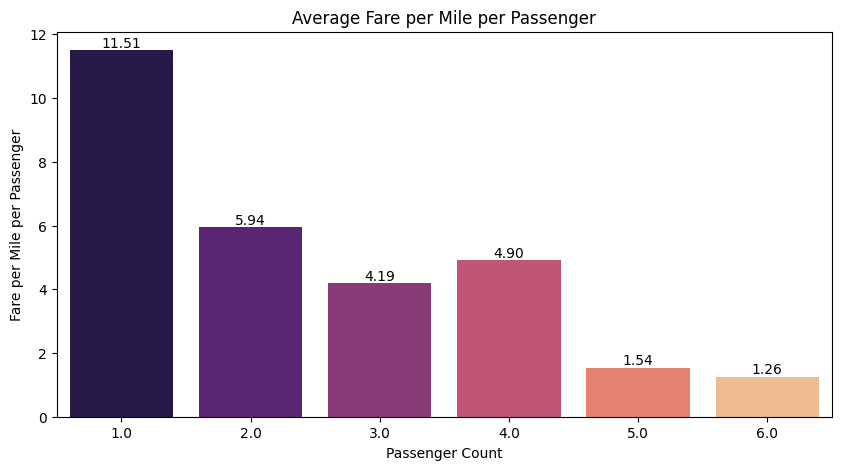

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=avg_fare,
    x='passenger_count',
    y='fare_per_mile_per_passenger',
    palette='magma'
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title('Average Fare per Mile per Passenger')
plt.xlabel('Passenger Count')
plt.ylabel('Fare per Mile per Passenger')

plt.show()

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [ ]:
# Compare the average fare per mile for different days and for different times of the day

# Calculate fare per mile

fare_df['fare_per_mile'] = (fare_df['fare_amount'] / fare_df['trip_distance'])

# Fare per mile by hours of the day and by days of the week
fare_by_day_hour = fare_df.groupby(['pickup_day', 'pickup_hour'])['fare_per_mile'].mean().reset_index(name='avg_fare_per_mile_by_hour')
fare_by_day_hour

,pickup_day,pickup_hour,avg_fare_per_mile_by_hour
0,Friday,0,6.893584
1,Friday,1,13.640348
2,Friday,2,6.520746
3,Friday,3,6.351795
4,Friday,4,5.696483
...,...,...,...
163,Wednesday,19,11.110739
164,Wednesday,20,17.047353
165,Wednesday,21,7.480739
166,Wednesday,22,13.835109


In [ ]:
# Pivot table
heatmap_data = fare_by_day_hour.pivot_table(values='avg_fare_per_mile_by_hour', index='pickup_day', columns='pickup_hour')
heatmap_data

pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
pickup_day,,,,,,,,,,,,,,,,,,,,,
Friday,6.893584,13.640348,6.520746,6.351795,5.696483,18.535375,6.802488,7.296929,8.577383,8.301711,...,9.087166,9.680642,13.562541,10.392505,9.844045,14.017692,9.080255,7.792870,9.085451,7.752159
Monday,21.848584,5.956156,6.423741,6.451049,5.697141,6.139572,9.876295,7.626036,9.744599,8.595032,...,13.488394,10.946130,8.200097,13.275391,15.033252,8.921690,8.911239,6.635143,11.596527,7.879375
Saturday,8.331906,8.507864,9.075917,6.609298,53.495792,16.405296,58.659182,6.418501,9.272171,6.963195,...,18.543460,10.355001,9.277580,8.843949,9.390802,9.100648,8.671199,8.714004,9.527262,9.941864
Sunday,7.473939,12.671345,10.283107,6.698389,6.307092,18.122768,9.686697,23.061576,6.283148,6.501250,...,9.894876,7.902840,12.160581,13.184674,9.435461,12.256362,8.422162,7.557944,34.902369,81.224591
Thursday,18.791152,28.894842,6.082293,18.037427,11.072637,7.687126,9.949726,7.132395,13.526914,10.901497,...,13.609421,14.978816,20.569919,12.704697,10.179530,16.785208,7.465684,11.699336,7.115374,7.177849
Tuesday,22.246559,89.645072,16.701567,79.430653,9.440030,5.815289,11.668023,7.864747,8.200933,17.078597,...,10.615986,9.536095,12.899659,9.756571,8.732944,9.224516,7.388878,11.242597,6.841531,6.418232
Wednesday,18.013895,6.580365,6.422220,6.102957,5.642715,6.248344,6.302165,9.356758,10.960417,8.702453,...,12.349412,10.954165,14.956145,14.401452,10.254663,11.110739,17.047353,7.480739,13.835109,6.413656


In [ ]:
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

heatmap_data = heatmap_data.reindex(day_order)
heatmap_data

pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
pickup_day,,,,,,,,,,,,,,,,,,,,,
Monday,21.848584,5.956156,6.423741,6.451049,5.697141,6.139572,9.876295,7.626036,9.744599,8.595032,...,13.488394,10.946130,8.200097,13.275391,15.033252,8.921690,8.911239,6.635143,11.596527,7.879375
Tuesday,22.246559,89.645072,16.701567,79.430653,9.440030,5.815289,11.668023,7.864747,8.200933,17.078597,...,10.615986,9.536095,12.899659,9.756571,8.732944,9.224516,7.388878,11.242597,6.841531,6.418232
Wednesday,18.013895,6.580365,6.422220,6.102957,5.642715,6.248344,6.302165,9.356758,10.960417,8.702453,...,12.349412,10.954165,14.956145,14.401452,10.254663,11.110739,17.047353,7.480739,13.835109,6.413656
Thursday,18.791152,28.894842,6.082293,18.037427,11.072637,7.687126,9.949726,7.132395,13.526914,10.901497,...,13.609421,14.978816,20.569919,12.704697,10.179530,16.785208,7.465684,11.699336,7.115374,7.177849
Friday,6.893584,13.640348,6.520746,6.351795,5.696483,18.535375,6.802488,7.296929,8.577383,8.301711,...,9.087166,9.680642,13.562541,10.392505,9.844045,14.017692,9.080255,7.792870,9.085451,7.752159
Saturday,8.331906,8.507864,9.075917,6.609298,53.495792,16.405296,58.659182,6.418501,9.272171,6.963195,...,18.543460,10.355001,9.277580,8.843949,9.390802,9.100648,8.671199,8.714004,9.527262,9.941864
Sunday,7.473939,12.671345,10.283107,6.698389,6.307092,18.122768,9.686697,23.061576,6.283148,6.501250,...,9.894876,7.902840,12.160581,13.184674,9.435461,12.256362,8.422162,7.557944,34.902369,81.224591


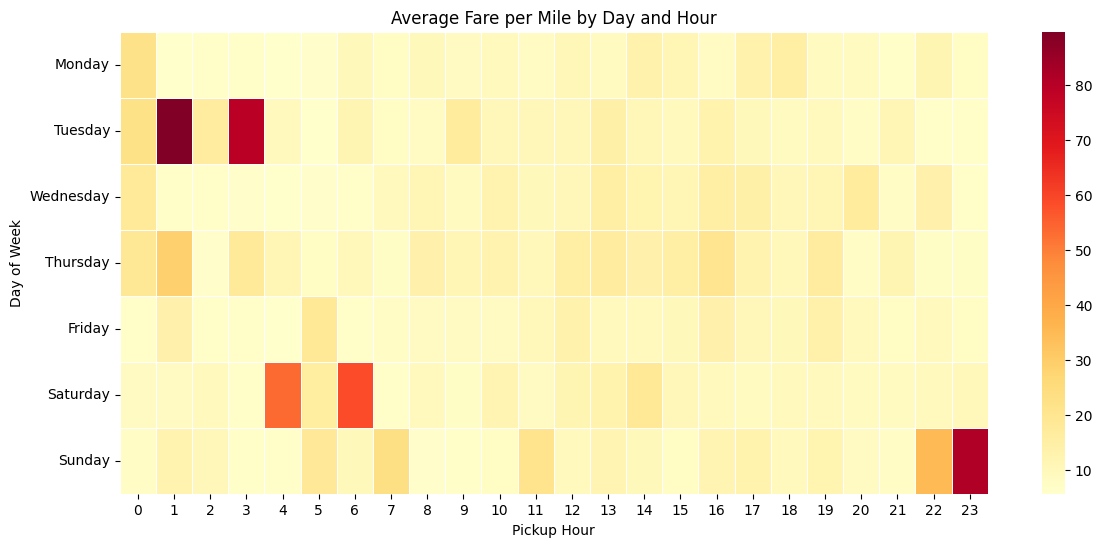

In [ ]:
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    linewidths=0.5
)

plt.title('Average Fare per Mile by Day and Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Day of Week')

plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [ ]:
fare_df['VendorID'].value_counts()

,count
VendorID,
2,201824
1,71104


In [ ]:
# Compare fare per mile for different vendors
vendor_fare_df = fare_df.groupby(['VendorID', 'pickup_hour'])['fare_per_mile'].mean().reset_index()
vendor_fare_df


,VendorID,pickup_hour,fare_per_mile
0,1,0,6.627990
1,1,1,7.185994
2,1,2,7.183884
3,1,3,6.418715
4,1,4,6.106004
5,1,5,6.756338
6,1,6,6.547619
7,1,7,7.238492
8,1,8,8.206433
9,1,9,8.122259


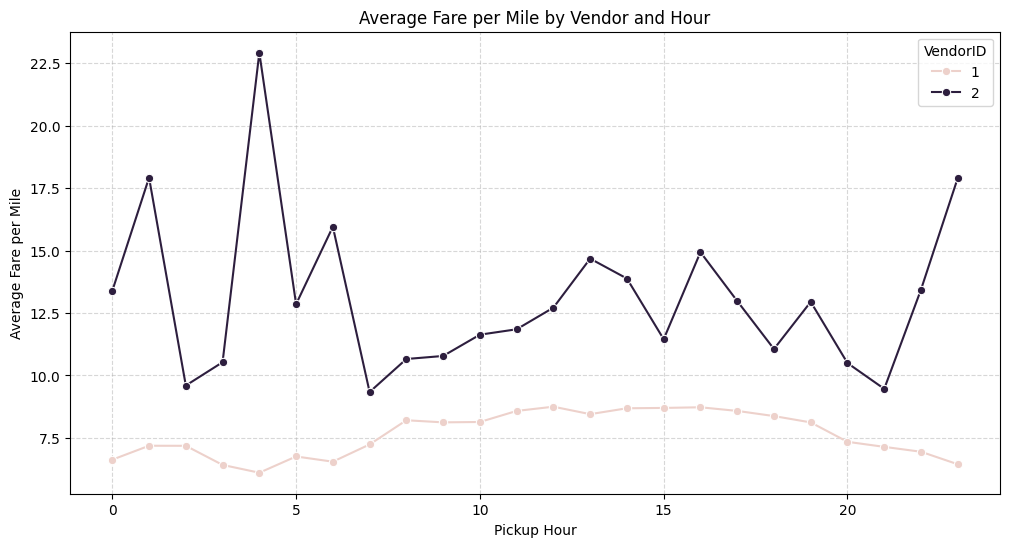

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=vendor_fare_df,
    x='pickup_hour',
    y='fare_per_mile',
    hue='VendorID',
    marker='o'
)

plt.title('Average Fare per Mile by Vendor and Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Fare per Mile')

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [ ]:
# Defining distance tiers

fare_df['distance_tier'] = pd.cut(
    fare_df['trip_distance'],
    bins=[0, 2, 5, float('inf')],
    labels=[
        'Up to 2 miles',
        '2 to 5 miles',
        'More than 5 miles'
    ]
)

fare_df['distance_tier']

,distance_tier
1,Up to 2 miles
2,More than 5 miles
3,More than 5 miles
4,Up to 2 miles
5,2 to 5 miles
...,...
285967,Up to 2 miles
285968,Up to 2 miles
285969,More than 5 miles
285970,2 to 5 miles


In [ ]:
tier_fare = fare_df.groupby(['VendorID', 'distance_tier'])['fare_per_mile'].mean().reset_index()
tier_fare

,VendorID,distance_tier,fare_per_mile
0,1,Up to 2 miles,9.698834
1,1,2 to 5 miles,6.298065
2,1,More than 5 miles,4.409116
3,2,Up to 2 miles,19.340400
4,2,2 to 5 miles,6.495798
5,2,More than 5 miles,4.474693


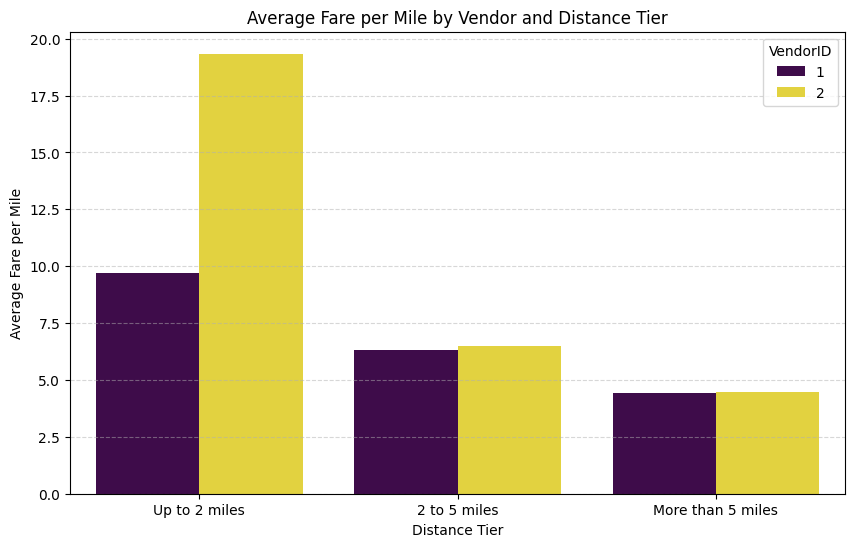

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=tier_fare,
    x='distance_tier',
    y='fare_per_mile',
    hue='VendorID',
    palette='viridis'
)

plt.title('Average Fare per Mile by Vendor and Distance Tier')
plt.xlabel('Distance Tier')
plt.ylabel('Average Fare per Mile')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [ ]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
# Calculate tip percentage
fare_df['tip_percentage'] = (fare_df['tip_amount'] / fare_df['fare_amount']) * 100

distance_tip = (fare_df.groupby(['distance_tier', 'passenger_count', 'pickup_hour'])['tip_percentage'].mean().reset_index())
distance_tip

,distance_tier,passenger_count,pickup_hour,tip_percentage
0,Up to 2 miles,1.0,0,23.322672
1,Up to 2 miles,1.0,1,25.121980
2,Up to 2 miles,1.0,2,23.493027
3,Up to 2 miles,1.0,3,24.680294
4,Up to 2 miles,1.0,4,20.519577
...,...,...,...,...
427,More than 5 miles,6.0,19,15.888542
428,More than 5 miles,6.0,20,15.543548
429,More than 5 miles,6.0,21,20.355705
430,More than 5 miles,6.0,22,13.220936


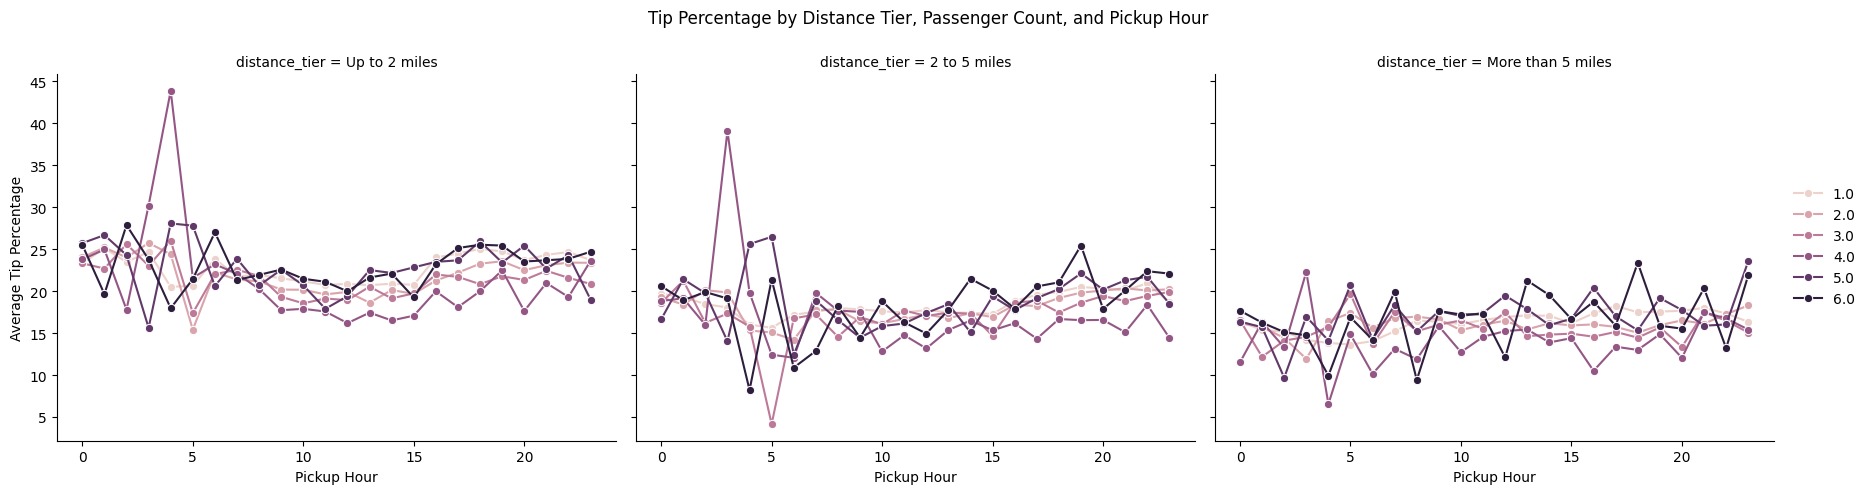

In [ ]:
g = sns.FacetGrid(distance_tip, col='distance_tier', height=5, aspect=1.2)

g.map_dataframe(
    sns.lineplot,
    x='pickup_hour',
    y='tip_percentage',
    hue='passenger_count',
    marker='o'
)

g.add_legend()

g.set_axis_labels(
    'Pickup Hour',
    'Average Tip Percentage'
)

g.fig.subplots_adjust(top=0.85)

g.fig.suptitle(
    'Tip Percentage by Distance Tier, Passenger Count, and Pickup Hour'
)

plt.show()


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

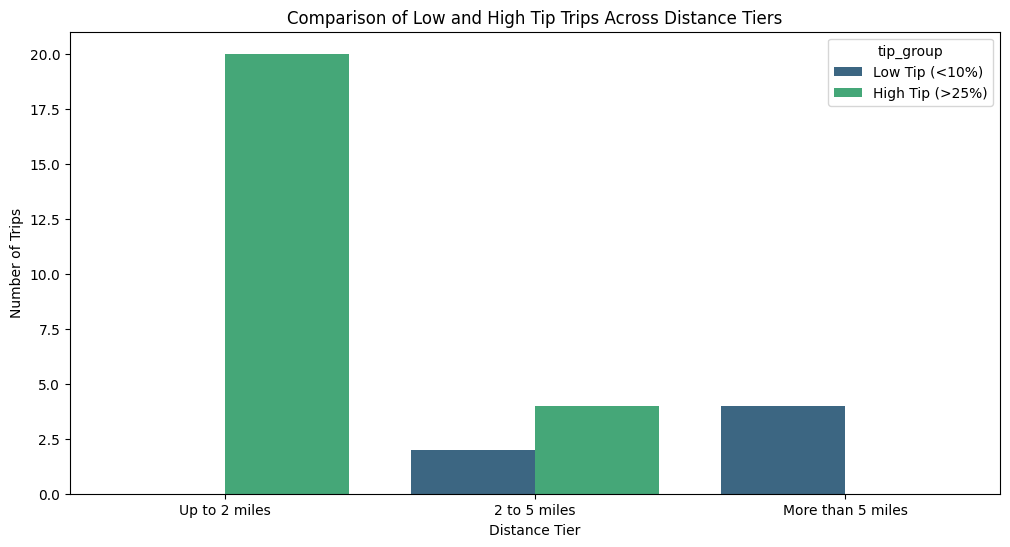

In [ ]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
# Create low-tip and high-tip groups
low_tip = distance_tip[distance_tip['tip_percentage'] < 10]
high_tip = distance_tip[distance_tip['tip_percentage'] > 25]

low_tip['tip_group'] = 'Low Tip (<10%)'
high_tip['tip_group'] = 'High Tip (>25%)'

# Combine datasets
tip_compare = pd.concat([low_tip, high_tip])

plt.figure(figsize=(12,6))

sns.countplot(
    data=tip_compare,
    x='distance_tier',
    hue='tip_group',
    palette='viridis'
)

plt.title('Comparison of Low and High Tip Trips Across Distance Tiers')
plt.xlabel('Distance Tier')
plt.ylabel('Number of Trips')

plt.show()

**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [ ]:
# See how passenger count varies across hours and days
clean_df.groupby(['pickup_hour', 'pickup_day', 'passenger_count']).size().reset_index(name='trip_count')


,pickup_hour,pickup_day,passenger_count,trip_count
0,0,Friday,1.0,863
1,0,Friday,2.0,177
2,0,Friday,3.0,40
3,0,Friday,4.0,21
4,0,Friday,5.0,12
...,...,...,...,...
995,23,Wednesday,2.0,712
996,23,Wednesday,3.0,220
997,23,Wednesday,4.0,110
998,23,Wednesday,5.0,47


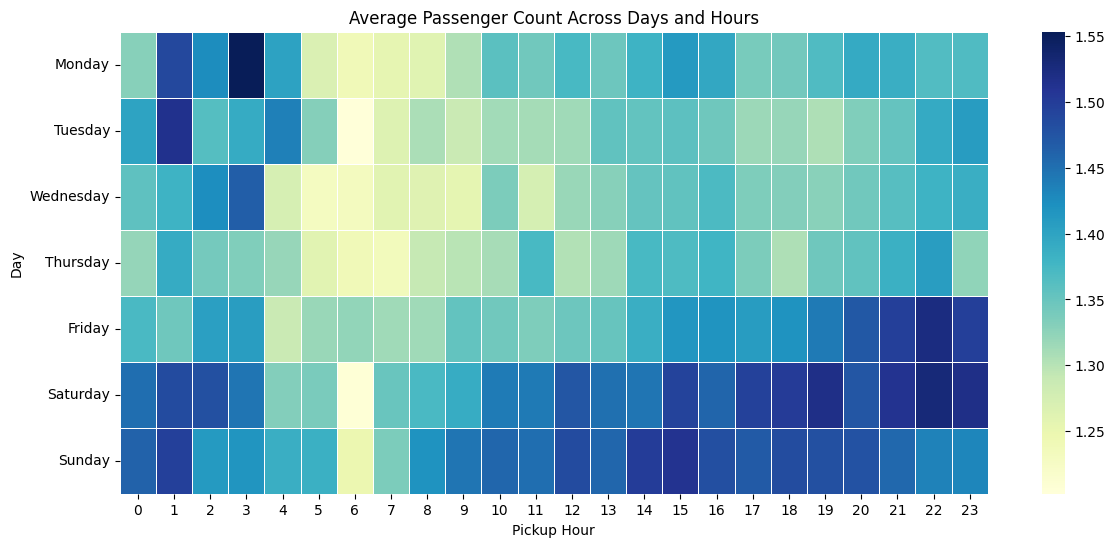

In [ ]:
heatmap_data = clean_df.pivot_table(
    index='pickup_day',
    columns='pickup_hour',
    values='passenger_count',
    aggfunc='mean'
)

heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title('Average Passenger Count Across Days and Hours')
plt.xlabel('Pickup Hour')
plt.ylabel('Day')

plt.show()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [ ]:
# How does passenger count vary across zones
clean_df.groupby(['PULocationID', 'passenger_count']).size().reset_index(name='trip_count')

,PULocationID,passenger_count,trip_count
0,1,1.0,23
1,1,2.0,5
2,1,3.0,3
3,1,4.0,4
4,3,1.0,7
...,...,...,...
723,264,6.0,13
724,265,1.0,102
725,265,2.0,18
726,265,3.0,8


In [ ]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

# Calculating average passenger count per pickup zone
avg_passenger_zone = (clean_df.groupby('PULocationID')['passenger_count'].mean().reset_index(name='avg_passenger_count'))

# Merging with GeoDataFrame
zones_with_trips = geo_df.merge(avg_passenger_zone, left_on='LocationID', right_on='PULocationID', how='left')
zones_with_trips[['LocationID', 'avg_passenger_count']].head()

,LocationID,avg_passenger_count
0,142,1.369878
1,132,1.469035
2,249,1.408604
3,144,1.502968
4,79,1.419667


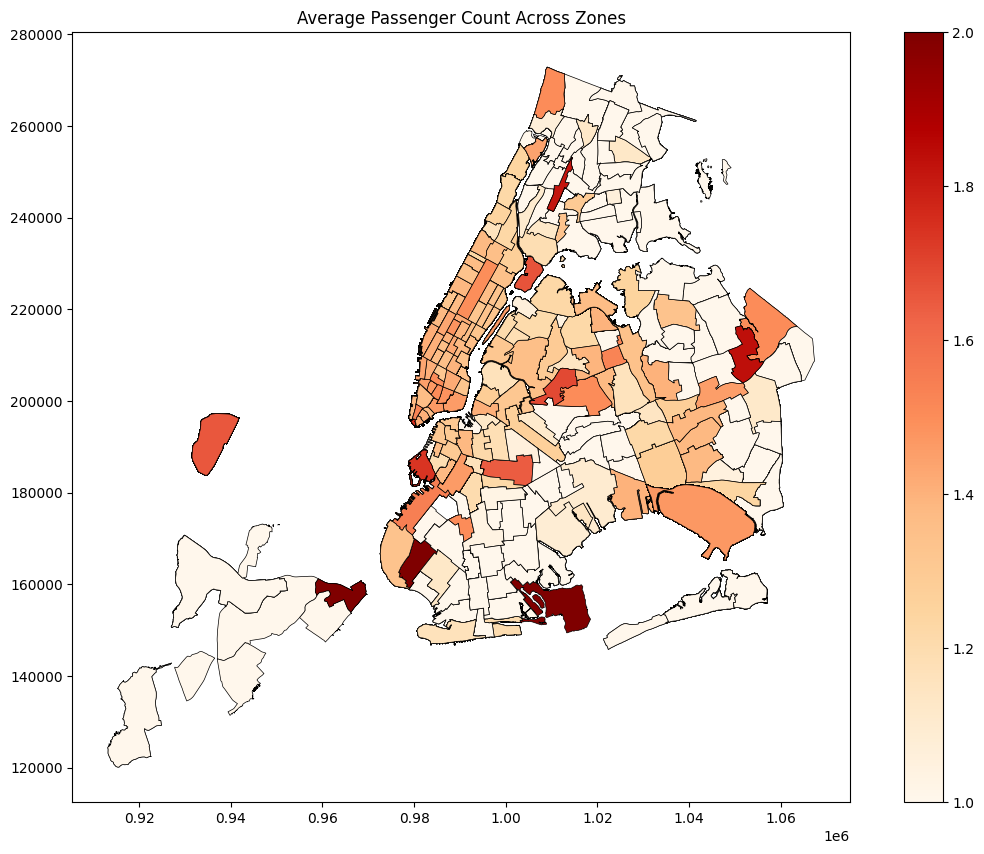

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(14,10))

zones_with_trips.plot(
    column='avg_passenger_count',
    cmap='OrRd',
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    ax=ax
)

ax.set_title('Average Passenger Count Across Zones')

plt.show()

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [ ]:
surcharge_columns = ['extra', 'congestion_surcharge', 'airport_fee_combined', 'improvement_surcharge']

# Calculate the frequency of each surcharge
surcharge_columns = ['extra', 'congestion_surcharge', 'airport_fee_combined', 'improvement_surcharge']
surcharge_frequencies = clean_df[surcharge_columns].apply(lambda x: (x > 0).sum()).reset_index()
surcharge_frequencies.columns = ['Surcharge', 'Frequency']

# Display the frequency of each surcharge
print("Frequency of each surcharge:")
print(surcharge_frequencies)

Frequency of each surcharge:
               Surcharge  Frequency
0                  extra     177039
1   congestion_surcharge     253820
2   airport_fee_combined          0
3  improvement_surcharge     275158


In [ ]:
# Create a flag to identify trips with any surcharge
clean_df['has_surcharge'] = (
    clean_df[surcharge_columns] > 0
).any(axis=1)

# Count surcharge trips by pickup zone
pickup_surcharge = clean_df.groupby(
    'PULocationID'
)['has_surcharge'].sum().reset_index(name='surcharge_count')

# Merge with zone lookup table
pickup_surcharge = pickup_surcharge.merge(
    geo_df[['LocationID', 'zone']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
).drop_duplicates()

# Sort zones by surcharge frequency
top_pickup_surcharge = pickup_surcharge.sort_values(
    by='surcharge_count',
    ascending=False
).head(10)

# Display results
print("Top pickup zones with surcharges:")
top_pickup_surcharge

Top pickup zones with surcharges:


,PULocationID,surcharge_count,LocationID,zone
63546,132,15452,132.0,JFK Airport
226123,237,12720,237.0,Upper East Side South
126104,161,12702,161.0,Midtown Center
214967,236,11156,236.0,Upper East Side North
81999,138,10054,138.0,LaGuardia Airport
138806,162,9753,162.0,Midtown East
172189,186,9556,186.0,Penn Station/Madison Sq West
190782,230,9548,230.0,Times Sq/Theatre District
103679,142,9103,142.0,Lincoln Square East
164064,170,7949,170.0,Murray Hill


In [ ]:
# Analyze the dropoff zones where surcharges are applied more frequently
dropoff_surcharge_zones = clean_df[clean_df[surcharge_columns].sum(axis=1) > 0].groupby('DOLocationID').size().reset_index(name='surcharge_count')
dropoff_surcharge_zones = dropoff_surcharge_zones.merge(zones[['LocationID', 'zone']], left_on='DOLocationID', right_on='LocationID', how='left').sort_values(by='surcharge_count', ascending=False)

# Display the top dropoff zones with surcharges
print("Top dropoff zones with surcharges:")
print(dropoff_surcharge_zones.head(10))

Top dropoff zones with surcharges:
     DOLocationID  surcharge_count  LocationID                       zone
226           236            11898       236.0      Upper East Side North
227           237            11148       237.0      Upper East Side South
154           161            10440       161.0             Midtown Center
220           230             8218       230.0  Times Sq/Theatre District
163           170             8057       170.0                Murray Hill
155           162             7696       162.0               Midtown East
135           142             7634       142.0        Lincoln Square East
229           239             7591       239.0      Upper West Side South
134           141             7173       141.0            Lenox Hill West
67             68             7026        68.0               East Chelsea


In [ ]:
# Analyze the times when surcharges are applied more frequently
clean_df['surcharge_applied'] = clean_df[surcharge_columns].sum(axis=1) > 0
surcharge_by_hour = clean_df.groupby('pickup_hour')['surcharge_applied'].sum().reset_index()

surcharge_by_hour = surcharge_by_hour.rename(
    columns={'surcharge_applied': 'surcharge_count'}
)

surcharge_by_hour

,pickup_hour,surcharge_count
0,0,7136
1,1,4813
2,2,3135
3,3,2040
4,4,1325
5,5,1369
6,6,3349
7,7,6851
8,8,9508
9,9,10922


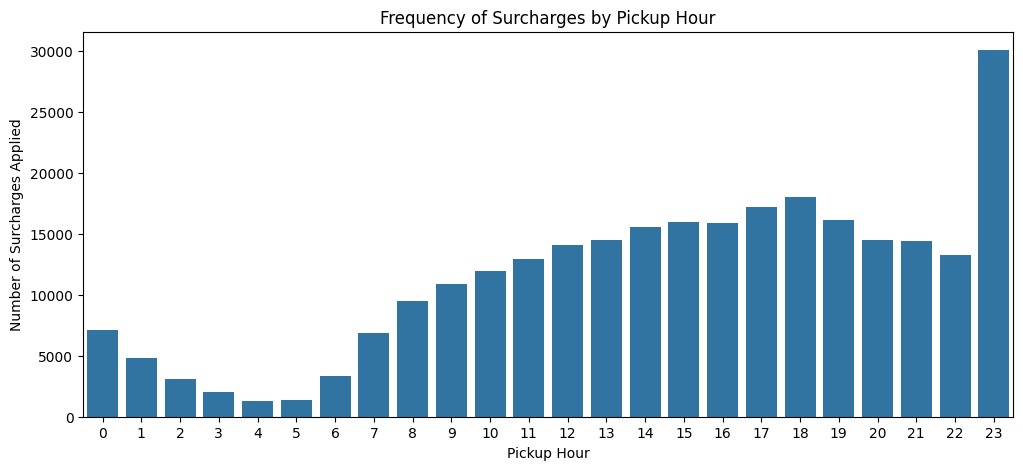

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=surcharge_by_hour,
    x='pickup_hour',
    y='surcharge_count'
)

plt.title('Frequency of Surcharges by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Number of Surcharges Applied')

plt.show()

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

• Allocate more drivers during the busiest hours, especially 15:00-19:00 and 23:00, while reducing idle supply during 03:00-05:00.

• Use route-hour speed analysis to flag bottlenecks and avoid dispatching drivers through slow routes when faster alternatives are available.

• Zones with strong pickup-dropoff imbalances should also be monitored carefully to reduce empty return trips and improve driver utilization.


**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

• Prioritise high-demand pickup zones such as LocationIDs 132, 237, 161, 236, 138, 162, 186, 230, 142, and 170.

• During night hours, position more cabs near high night pickup zones such as 132, 138, 230, 48, and 79.

• Use pickup/dropoff ratio analysis to reposition vehicles from zones with high dropoffs but low pickups toward zones with stronger outgoing demand.

• Increase airport and Manhattan availability during high-revenue months and quarters, especially Q2 and Q4.


**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

• Maintain competitive fares for 2-5 mile and more-than-5-mile trips because vendor differences are small in these tiers.

• Review short-distance pricing because fare per mile is much higher for short trips, especially for Vendor 2; this may improve revenue but can reduce customer satisfaction if perceived as expensive.

• Use time-sensitive pricing carefully during high-demand late-evening and peak periods, while monitoring tip percentages and payment behaviour.

• Promote card/digital payments because they are associated with clearer tip capture and more complete customer-spend data.


Overall, the analysis shows that NYC taxi operations can be improved by combining time-based demand planning, spatial positioning, route-level speed monitoring, and distance-tiered pricing insights. The strongest operational opportunities are better fleet placement during peak hours, smarter repositioning between pickup-heavy and dropoff-heavy zones, and careful pricing review for short trips and surcharge-heavy locations.